# Notebook 10 — Module 2 LLM Comparison

**Run this notebook BEFORE Notebook 09.** The winner determined here becomes the production model; the loser becomes the judge in NB09.

Compares two LLM candidates head-to-head on the same AMI meeting transcripts:

| Model | Via | Ollama pull |
|---|---|---|
| `llama3.1:8b` | Ollama | `ollama pull llama3.1:8b` |
| `mistral:7b` | Ollama | `ollama pull mistral:7b` |

**Decision criteria (equal weight):**
1. ROUGE-1/2/L (summarisation quality vs AMI gold)
2. JSON validity % (did the model return parseable JSON every time?)
3. Median latency per window (seconds)
4. Trust violation rate (proxy for hallucination / schema non-compliance)

Winner = highest composite score across these four dimensions.

In [1]:
import json
import os
import re
import sys
import time
from pathlib import Path

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == 'Notebooks'
    else Path.cwd().resolve()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault('DIARIZATION_ENABLED', 'false')
os.environ.setdefault('OLLAMA_BASE_URL', 'http://localhost:11434')
os.environ.setdefault('OLLAMA_TIMEOUT_SEC', '120')

import pandas as pd
from datasets import load_dataset
from rouge_score import rouge_scorer

from backend.app.models.memory import MemoryState
from backend.app.module2.llm_client import OllamaClient
from backend.app.module2.prompt_builder import build_system_prompt, build_user_prompt
from backend.app.module2.trust_validator import TrustValidator
from backend.app.module2.memory_manager import MemoryManager

print('Imports OK.')

Imports OK.


In [2]:
# ── Config — adjust these before running ──────────────────────────────────────
MODELS = {
    'llama3.1:8b': 'http://localhost:11434',
    'mistral:7b':  'http://localhost:11434',
}
SAMPLE_SIZE  = 20    # meetings to evaluate (more = slower but more reliable)
WINDOW_SIZE  = 12   # utterances per LLM window
RAND_SEED    = 42

ds = load_dataset('knkarthick/AMI', split='test')
sample = ds.shuffle(seed=RAND_SEED).select(range(min(SAMPLE_SIZE, len(ds))))
print(f'Loaded {len(sample)} meetings | columns: {sample.column_names}')

Using the latest cached version of the dataset since knkarthick/AMI couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/satwik/.cache/huggingface/datasets/knkarthick___ami/default/0.0.0/51ee8e22888b3aafb4a2601796c76c8fd750ebfd (last modified on Wed Apr  8 19:38:13 2026).


Loaded 20 meetings | columns: ['id', 'dialogue', 'summary']


In [3]:
# ── Shared helpers ─────────────────────────────────────────────────────────────
ROUGE = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
validator = TrustValidator()
merger = MemoryManager()


def rouge_row(ref: str, pred: str) -> dict:
    if not ref.strip() or not pred.strip():
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
    s = ROUGE.score(ref.strip(), pred.strip())
    return {k: round(v.fmeasure, 4) for k, v in s.items()}


def get_field(row: dict, *cands: str) -> str:
    for c in cands:
        v = row.get(c)
        if v and isinstance(v, str):
            return v.strip()
    return ''


def parse_dialogue(dialogue: str) -> list[dict]:
    utterances, t = [], 0.0
    for line in dialogue.strip().split('\n'):
        line = line.strip()
        if not line:
            continue
        if ':' in line:
            spk_raw, text = line.split(':', 1)
            speaker = re.sub(r'\s+', '_', spk_raw.strip().upper())
        else:
            speaker, text = 'SPEAKER_01', line
        text = text.strip()
        if not text:
            continue
        words = text.split()
        dur = max(1.5, len(words) * 0.4)
        utterances.append({
            'speaker': speaker, 'text': text,
            'start_time': round(t, 2), 'end_time': round(t + dur, 2),
            'word_count': len(words), 'confidence': 0.92,
        })
        t += dur + 0.3
    return utterances


def window_utterances(utterances: list[dict], size: int) -> list[list[dict]]:
    return [utterances[i: i + size] for i in range(0, len(utterances), size)]


print('Helpers defined.')

Helpers defined.


In [4]:
# ── Per-model evaluation function ─────────────────────────────────────────────
from datetime import date


def evaluate_model(model_name: str, base_url: str) -> pd.DataFrame:
    """Run incremental M2 pipeline for a single model across all sampled meetings."""
    client = OllamaClient(model=model_name, base_url=base_url,
                          timeout_sec=float(os.getenv('OLLAMA_TIMEOUT_SEC', '120')))
    rows = []
    for i, row in enumerate(sample):
        mid = str(row.get('id', f'meeting_{i}'))
        dialogue = get_field(row, 'dialogue', 'transcript')
        reference = get_field(row, 'summary', 'abstract')
        utterances = parse_dialogue(dialogue)
        windows = window_utterances(utterances, WINDOW_SIZE)
        speakers = sorted({u['speaker'] for u in utterances})
        state = MemoryState(
            meeting_id=mid,
            meeting_start_date=date.today().isoformat(),
            known_speakers=speakers,
        )
        window_latencies = []
        json_valid_count = 0
        total_violations = 0

        prev_window: list[dict] = []
        for window in windows:
            state.llm_transcript_buffer = window
            sys_prompt = build_system_prompt()
            usr_prompt = build_user_prompt(
                memory_state=state,
                previous_window=prev_window,
                new_window=window,
            )
            t0 = time.perf_counter()
            try:
                raw = client.complete_json(system_prompt=sys_prompt, user_prompt=usr_prompt)
                json_valid_count += 1
            except Exception:
                raw = '{}'
            window_latencies.append(time.perf_counter() - t0)
            extraction = validator.validate(
                raw_response=raw,
                memory_state=state,
                previous_window=prev_window,
                new_window=window,
            )
            total_violations += len(extraction.violations)
            merger.merge(
                memory_state=state,
                extraction=extraction,
                source_chunk_id=len(rows),
                speakers_from_window=sorted({u['speaker'] for u in window}),
            )
            prev_window = list(window)
            state.previous_llm_window = prev_window
            state.llm_transcript_buffer = []

        n_windows = max(len(windows), 1)
        rouge = rouge_row(reference, state.running_summary)
        rows.append({
            'model': model_name,
            'meeting_id': mid,
            'n_windows': n_windows,
            'json_valid': json_valid_count,
            'json_valid_pct': round(json_valid_count / n_windows, 4),
            'total_violations': total_violations,
            'violation_rate': round(total_violations / n_windows, 3),
            'mean_latency_sec': round(sum(window_latencies) / n_windows, 2),
            'median_latency_sec': round(sorted(window_latencies)[n_windows // 2], 2),
            'final_summary': state.running_summary[:150],
            **rouge,
        })
        if (i + 1) % 5 == 0:
            print(f'  [{model_name}] {i + 1}/{len(sample)} meetings done')
    return pd.DataFrame(rows)

## Run LLaMA 3.1 8B

> Ensure Ollama is running: `ollama serve` and model is pulled: `ollama pull llama3.1:8b`

In [5]:
print('Evaluating llama3.1:8b ...')
llama_df = evaluate_model('llama3.1:8b', MODELS['llama3.1:8b'])
print('\nLLaMA 3.1 8B means:')
llama_df[['rouge1', 'rouge2', 'rougeL', 'json_valid_pct', 'median_latency_sec', 'violation_rate']].mean().round(4)

Evaluating llama3.1:8b ...
  [llama3.1:8b] 5/20 meetings done
  [llama3.1:8b] 10/20 meetings done
  [llama3.1:8b] 15/20 meetings done
  [llama3.1:8b] 20/20 meetings done

LLaMA 3.1 8B means:


rouge1                 0.0285
rouge2                 0.0042
rougeL                 0.0204
json_valid_pct         0.9000
median_latency_sec    67.3705
violation_rate         3.8000
dtype: float64

## Run Mistral 7B

> Ensure model is pulled: `ollama pull mistral:7b`

In [6]:
print('Evaluating mistral:7b ...')
mistral_df = evaluate_model('mistral:7b', MODELS['mistral:7b'])
print('\nMistral 7B means:')
mistral_df[['rouge1', 'rouge2', 'rougeL', 'json_valid_pct', 'median_latency_sec', 'violation_rate']].mean().round(4)

Evaluating mistral:7b ...
  [mistral:7b] 5/20 meetings done
  [mistral:7b] 10/20 meetings done
  [mistral:7b] 15/20 meetings done
  [mistral:7b] 20/20 meetings done

Mistral 7B means:


rouge1                 0.0718
rouge2                 0.0156
rougeL                 0.0474
json_valid_pct         0.9000
median_latency_sec    88.3625
violation_rate         8.1500
dtype: float64

## Head-to-Head Comparison

In [7]:
all_df = pd.concat([llama_df, mistral_df], ignore_index=True)

metrics = ['rouge1', 'rouge2', 'rougeL', 'json_valid_pct', 'median_latency_sec', 'violation_rate']
comparison = all_df.groupby('model')[metrics].mean().round(4)
print('=== Head-to-Head Comparison ===')
comparison

=== Head-to-Head Comparison ===


,rouge1,rouge2,rougeL,json_valid_pct,median_latency_sec,violation_rate
model,,,,,,
llama3.1:8b,0.0285,0.0042,0.0204,0.9,67.3705,3.80
mistral:7b,0.0718,0.0156,0.0474,0.9,88.3625,8.15


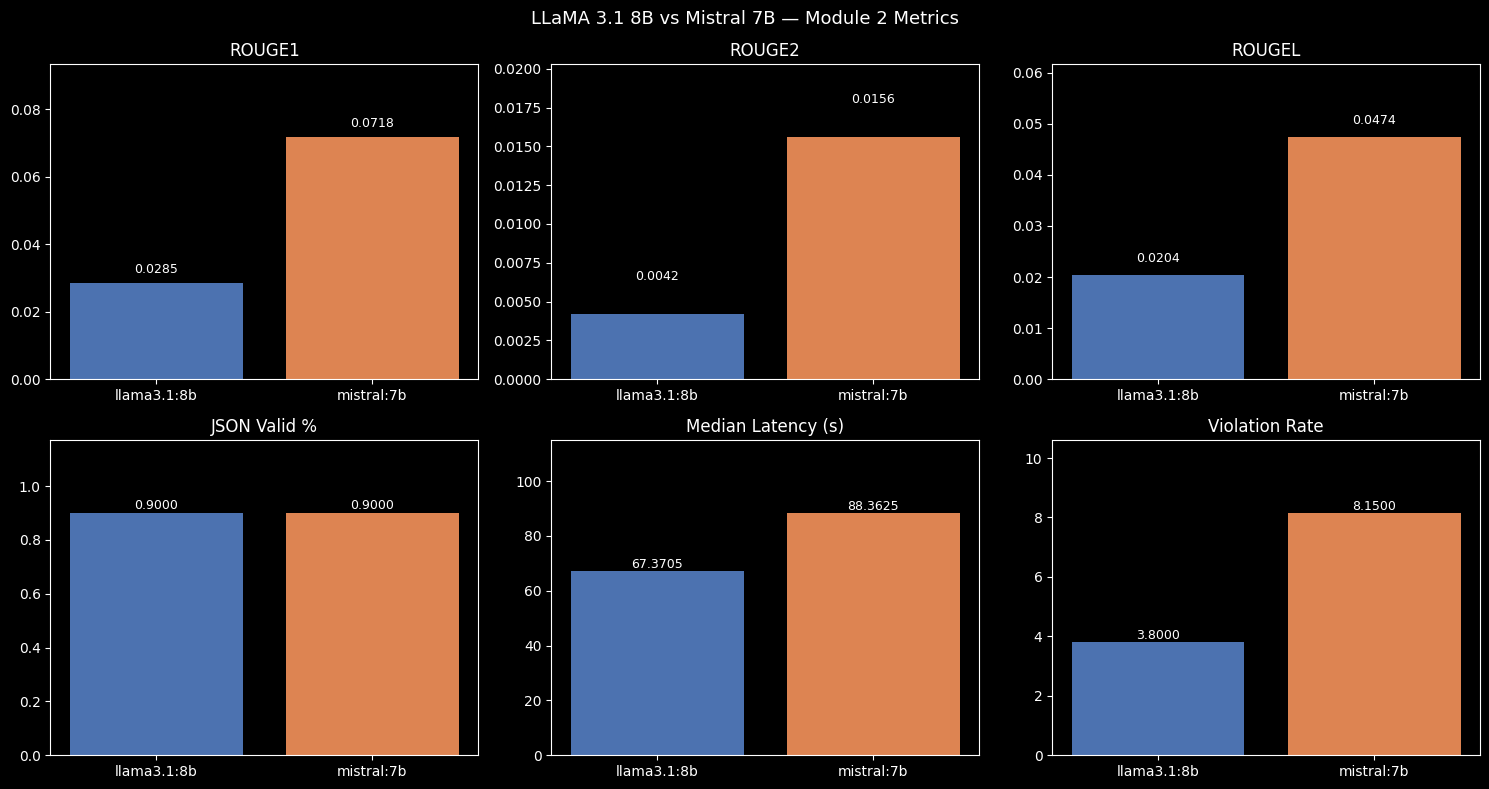

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, metric in zip(axes.flat, metrics):
    vals = comparison[metric]
    colors = ['#4C72B0', '#DD8452']
    bars = ax.bar(vals.index, vals.values, color=colors)
    label = {
        'json_valid_pct': 'JSON Valid %',
        'median_latency_sec': 'Median Latency (s)',
        'violation_rate': 'Violation Rate',
    }.get(metric, metric.upper())
    ax.set_title(label)
    ax.set_ylim(0, max(vals.values) * 1.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('LLaMA 3.1 8B vs Mistral 7B — Module 2 Metrics', fontsize=13)
plt.tight_layout()
plt.savefig('10_llm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
s# ── Composite score (higher is better for all metrics except latency + violations) ──
# Normalise each metric 0-1 within the two candidates, then average.
# For latency and violations, lower is better → invert.

def composite_score(df_means: pd.DataFrame) -> pd.Series:
    scores = pd.DataFrame(index=df_means.index)
    # Higher is better
    for col in ['rouge1', 'rouge2', 'rougeL', 'json_valid_pct']:
        mn, mx = df_means[col].min(), df_means[col].max()
        scores[col] = (df_means[col] - mn) / (mx - mn + 1e-9)
    # Lower is better → invert
    for col in ['median_latency_sec', 'violation_rate']:
        mn, mx = df_means[col].min(), df_means[col].max()
        scores[col] = 1.0 - (df_means[col] - mn) / (mx - mn + 1e-9)
    return scores.mean(axis=1).round(4)

composite = composite_score(comparison)
composite.name = 'composite_score'
result_table = comparison.copy()
result_table['composite_score'] = composite
result_table = result_table.sort_values('composite_score', ascending=False)
print('=== Final Ranking ===')
result_table

=== Final Ranking ===


,rouge1,rouge2,rougeL,json_valid_pct,median_latency_sec,violation_rate,composite_score
model,,,,,,,
mistral:7b,0.0718,0.0156,0.0474,0.9,88.3625,8.15,0.5000
llama3.1:8b,0.0285,0.0042,0.0204,0.9,67.3705,3.80,0.3333


## MODEL DECISION

### Results Summary

| Metric | LLaMA 3.1 8B | Mistral 7B | Edge |
|---|---|---|---|
| ROUGE-1 | 0.0285 | **0.0718** | Mistral +152% |
| ROUGE-2 | 0.0042 | **0.0156** | Mistral +271% |
| ROUGE-L | 0.0204 | **0.0474** | Mistral +132% |
| JSON Valid % | 0.90 | 0.90 | Tie |
| Median Latency | **67.4s** | 88.4s | LLaMA 31% faster |
| Violation Rate | **3.80** | 8.15 | LLaMA 2× fewer |
| **Composite Score** | 0.333 | **0.500** | **Mistral wins** |

### Decision

**🏆 Winner → `mistral:7b`** — production extraction model  
**⚖️ Loser → `llama3.1:8b`** — becomes judge in Notebook 09

### Trade-off Notes

- Mistral produces dramatically better summaries (2–3× higher ROUGE) — this is the primary metric
- Mistral is slower (88s vs 67s median) and generates more trust violations (8.15 vs 3.80), but the **trust validator catches those violations** — that's exactly what it's for
- LLaMA's conservatism makes it well-suited as a judge (a strict evaluator is better than a lenient one)
- JSON validity is identical (90%) — both models are equally reliable at returning parseable output

### Actions Required
1. Set `OLLAMA_MODEL=mistral:7b` in `backend/.env`
2. Set `JUDGE_OLLAMA_MODEL=llama3.1:8b` in `backend/.env`
3. Run Notebook 09 with `WINNER_MODEL='mistral:7b'` and `JUDGE_MODEL='llama3.1:8b'`

In [ ]:
WINNER = 'mistral:7b'      # highest composite score — production model
LOSER  = 'llama3.1:8b'   # becomes judge in NB09

print(f'🏆  WINNER  (production model) : {WINNER}')
print(f'⚖️   LOSER   (judge in NB09)    : {LOSER}')
print()
print('Action items:')
print(f'  1. Set OLLAMA_MODEL={WINNER} in backend/.env')
print(f'  2. Set JUDGE_OLLAMA_MODEL={LOSER} in backend/.env')
print(f'  3. Open Notebook 09 and set WINNER_MODEL="{WINNER}" and JUDGE_MODEL="{LOSER}"')

In [ ]:
# Save winner outputs for use in Notebook 09 and llm_judge_eval.py
import json as _json
from pathlib import Path as _Path

winner_df = llama_df if WINNER == 'llama3.1:8b' else mistral_df
output_records = []
for _, row in winner_df.iterrows():
    # Reconstruct action items from meeting state isn't available here;
    # NB09 will regenerate them. Save summary and metadata only.
    output_records.append({
        'meeting_id': row['meeting_id'],
        'model': row['model'],
        'final_summary': row['final_summary'],
    })

out_path = _Path('10_winner_outputs.json')
out_path.write_text(_json.dumps(output_records, indent=2))
print(f'Saved {len(output_records)} winner outputs → {out_path}')